We want to solve the problem
\begin{align}
    -\frac{\mu}{2} \text{div}(\nabla u + \nabla u^T) &= \nabla p \quad &\text{ in } \Omega
    \\
    \text{div}(u) &= 0&\text{ in } \Omega
\end{align}
Where $\Omega$ is a round pipe. At the inflow of the pipe we give some velocity profile $u_{in}$ at the outflow we say $p=0$ (set the pressure to some value) and at the walls we have $u=0$.

In [1]:
import qewton

In [2]:
X = qewton.Variable("x", 3)
N = qewton.Variable("n", 3) # normal vectors
U = qewton.Variable("u", 3) # velocity is vector valued
P = qewton.Variable("p", 1) # pressure is scalar

mu = 0.001

In [3]:
mesh_geo = qewton.geometries.MeshGeometry.load_mesh(
    variable=X, file_path="data/stokes_pipe/u_pipe.msh"
)

inflow_goe = mesh_geo.boundary.get_submesh("Inflow")
outflow_geo = mesh_geo.boundary.get_submesh("Outflow")
side_geo = mesh_geo.boundary.get_submesh("Side")

/home/tomfre/Desktop/pioneer-backend/src/qewton/backends/torch/base.py:89: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  return torch.as_tensor(data, dtype=converted_type)


In [4]:
volume_sampler = qewton.RandomUniformSampler(mesh_geo, 60000)
inflow_sampler = qewton.RandomUniformSampler(inflow_goe, 8000)
outflow_sampler = qewton.RandomUniformSampler(outflow_geo, 8000, compute_normals=True, normal_name=N)
side_sampler = qewton.RandomUniformSampler(side_geo, 15000)

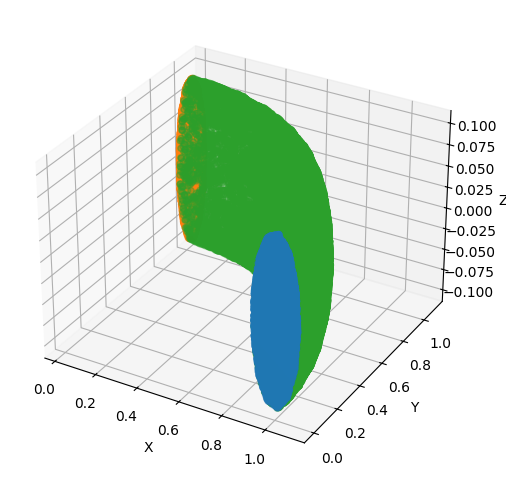

In [ ]:
# Point sampling:
import matplotlib.pyplot as plt

in_points = inflow_sampler()
out_points = outflow_sampler()[0]
side_points = side_sampler()
# Create figure
fig = plt.figure(figsize=(8, 6))

# Add 3D axes
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(out_points[:, 0], out_points[:, 1], out_points[:, 2])
ax.scatter(side_points[:, 0], side_points[:, 1], side_points[:, 2])
ax.scatter(in_points[:, 0], in_points[:, 1], in_points[:, 2])

# Axis labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()
# Perspective is sometimes a bit broken:

In [22]:
model = qewton.FCN(
    in_neurons=X,
    hidden_neurons=40,
    out_neurons=U+P,
    n_hidden_layers=6,
    activation=qewton.bb.Tanh,
)

In [23]:
def momentum_residual(u: U, p: P, x: X):  # type: ignore
    return mu * u.sym_grad(x).matrix_div(x) - p.gradient(x)

momentum_graph = qewton.PINNPipeline(volume_sampler, [model], 
                                     residual=momentum_residual, 
                                     residual_name="MomentumConstraint", 
                                     weight=100.0)
momentum_constraint = momentum_graph.constraint

In [24]:
def mass_residual(u: U, x: X):  # type: ignore
    return u.div(x)

mass_graph = qewton.PINNPipeline(volume_sampler, [model], 
                                 residual=mass_residual, 
                                 residual_name="MassConstraint", 
                                 weight=500.0)
mass_constraint = mass_graph.constraint

In [25]:
def inflow_residual(u: U, x: X):  # type: ignore
    inflow_function = qewton.bb.ZerosLike()(x)
    inflow_function[:, 1] = - ((x[:, 0]-1.0)**2 + x[:, 2]**2 - 0.01)/0.01
    return u - inflow_function

in_graph = qewton.PINNPipeline(inflow_sampler, [model], 
                                residual=inflow_residual, 
                                residual_name="InConstraint", 
                                weight=1.0)
in_constraint = in_graph.constraint

In [26]:
def no_slip_residual(u: U):  # type: ignore
    return u

no_slip_graph = qewton.PINNPipeline(side_sampler, [model], 
                                    residual=no_slip_residual, 
                                    residual_name="SlipConstraint", 
                                    weight=100.0)
no_slip_constraint = no_slip_graph.constraint

In [27]:
def outflow_residual(p: P):  # type: ignore
    return p

out_graph = qewton.PINNPipeline(outflow_sampler, [model], 
                                residual=outflow_residual, 
                                residual_name="OutConstraint", 
                                weight=1.0)
out_constraint = out_graph.constraint

In [28]:
# Train inflow boundary condition first:
adam_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.Adam(),
    lr=0.001,
    max_iterations=10000,
)


trainer = qewton.optim.GraphBasedTrainer(
    optimization_phases=[adam_phase],
    graphs=[in_graph],
    training_objectives=[in_constraint],
    device=qewton.cuda(1),
)

trainer.run()

Optimization Phase 1: 100%|██████████| 10000/10000 [00:48<00:00, 204.24it/s, loss=4.77e-5]


In [29]:
# Train all other boundary condition:
adam_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.Adam(),
    lr=0.0005,
    max_iterations=10000,
)


trainer = qewton.optim.GraphBasedTrainer(
    optimization_phases=[adam_phase],
    graphs=[in_graph, out_graph, no_slip_graph],
    training_objectives=[in_constraint, out_constraint, no_slip_constraint],
    device=qewton.cuda(1),
)

trainer.run()

Optimization Phase 1: 100%|██████████| 10000/10000 [01:39<00:00, 100.43it/s, loss=0.055]


In [30]:
adam_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.Adam(),
    lr=0.0001,
    max_iterations=5000,
)

lbfgs_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.LBFGS(),
    lr=0.1,
    max_iterations=1000,
    optimizer_args={"max_eval": 20},
)

fix_sampler_callback = qewton.optim.CacheDataCallback(
    data_nodes=[volume_sampler, inflow_sampler, side_sampler, outflow_sampler],
    phase_to_start_cache=lbfgs_phase
)

trainer = qewton.optim.GraphBasedTrainer(
    optimization_phases=[adam_phase, lbfgs_phase],
    graphs=[momentum_graph, mass_graph, in_graph, out_graph, no_slip_graph],
    callbacks=[fix_sampler_callback],
    training_objectives=[momentum_constraint, mass_constraint, in_constraint, 
                         out_constraint, no_slip_constraint],
    device=qewton.cuda(1),
)

trainer.run()

Optimization Phase 2: 100%|██████████| 1000/1000 [56:21<00:00,  3.38s/it, loss=0.0195]


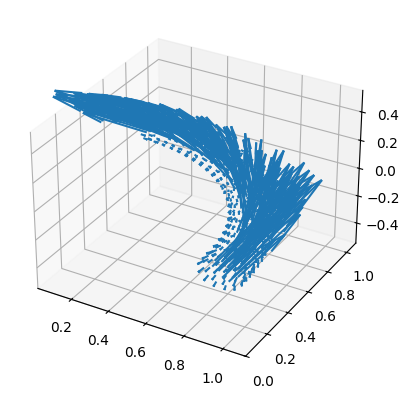

MSE between PINN and FEM: 0.018313185655650006
Relative MSE: 4.069929275363349


/tmp/ipykernel_1618142/1832045556.py:36: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  error_point_wise = np.linalg.norm(model_out-fem_velocity, ord=2, axis=1)


In [35]:
import torch
import matplotlib.pyplot as plt
import numpy as np 

fem_velocity = np.load("./data/stokes_pipe/velocity.npy")
mesh_coords = np.load("./data/stokes_pipe/mesh_coords.npy").astype(np.float32)

model.to("cpu")
model_out = model(torch.tensor(mesh_coords))[:, :3].detach().cpu()

x, y, z = mesh_coords[:, 0], mesh_coords[:, 1], mesh_coords[:, 2]
u, v, w = model_out[:, 0], model_out[:, 1], model_out[:, 2]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.quiver(
    x, y, z,
    u, v, w,
    length=1.0
)

mid_x = (x.max() + x.min()) * 0.5
mid_y = (y.max() + y.min()) * 0.5
mid_z = (z.max() + z.min()) * 0.5

max_range = (
    np.array([x.max() - x.min(), y.max() - y.min(), z.max() - z.min()]).max() / 2.0
)

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.show()
error_point_wise = np.linalg.norm(model_out-fem_velocity, ord=2, axis=1)
velocity_l2 = np.linalg.norm(fem_velocity, ord=2, axis=1)
mse_error = np.mean(error_point_wise**2)
print("MSE between PINN and FEM:", mse_error)
print("Relative MSE:", np.mean((error_point_wise / (velocity_l2 + 1.e-2))**2))

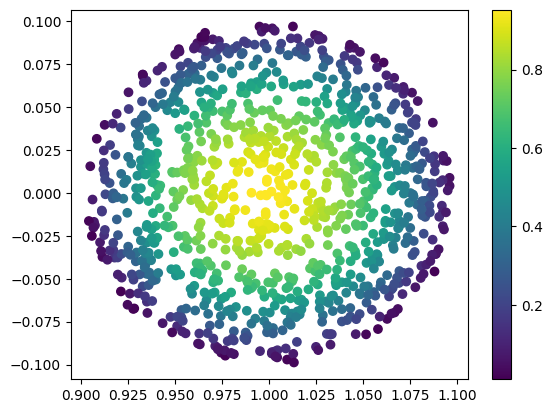

In [32]:
inflow_sampler = qewton.RandomUniformSampler(inflow_goe, 1000)
p = inflow_sampler()
u = model(p)[:, :3]
u_in = torch.zeros_like(p)
u_in[:, 1] = - ((p[:, 0]-1.0)**2 + p[:, 2]**2 - 0.01)/0.01
plt.scatter(p[:, 0], p[:, 2], c=torch.linalg.norm(u, axis=1).detach().cpu())
plt.colorbar()